强化学习教学代码：Q-learning在网格世界中的应用

1. 创建网格世界环境
环境初始化完成：
- 网格大小：5x5
- 起点位置：(0, 0)
- 终点位置：(4, 4)
- 障碍物位置：[(1, 1), (2, 3), (3, 1)]
- 动作空间：['上', '下', '左', '右']

2. 创建Q-learning智能体
Q-learning智能体初始化完成：
- 状态空间大小：25
- 动作空间大小：4
- 学习率α：0.1
- 折扣因子γ：0.9
- 探索率ε：0.1
- Q表形状：(25, 4)

3. 开始训练智能体
开始训练，总回合数：1000

回合 0，步骤 1:
步骤: 1
S . . . .
A X . . .
. . . X .
. X . . .
. . . . G
----------
动作: 下, 奖励: -0.10, 信息: 正常移动
回合 100/1000 - 平均奖励: 7.24, 平均步数: 13.4

回合 100，步骤 1:
步骤: 1
S A . . .
. X . . .
. . . X .
. X . . .
. . . . G
----------
动作: 右, 奖励: -0.10, 信息: 正常移动
回合 200/1000 - 平均奖励: 8.45, 平均步数: 9.2

回合 200，步骤 1:
步骤: 1
S A . . .
. X . . .
. . . X .
. X . . .
. . . . G
----------
动作: 右, 奖励: -0.10, 信息: 正常移动
回合 300/1000 - 平均奖励: 8.33, 平均步数: 9.4

回合 300，步骤 1:
步骤: 1
S A . . .
. X . . .
. . . X .
. X . . .
. . . . G
----------
动作: 右, 奖励: -0.10, 信息: 正常移动
回合 400/1000 - 平均奖励: 8.31, 平均步数: 9.1

回合 400，步骤 1:
步骤: 1
S A . . .
. X . . .
. . . X .
. X . . .
. . . . G
----------
动作: 右, 奖励: -0.10, 信息: 正常移动
回合 500/1000 - 平均奖励: 8.23, 平

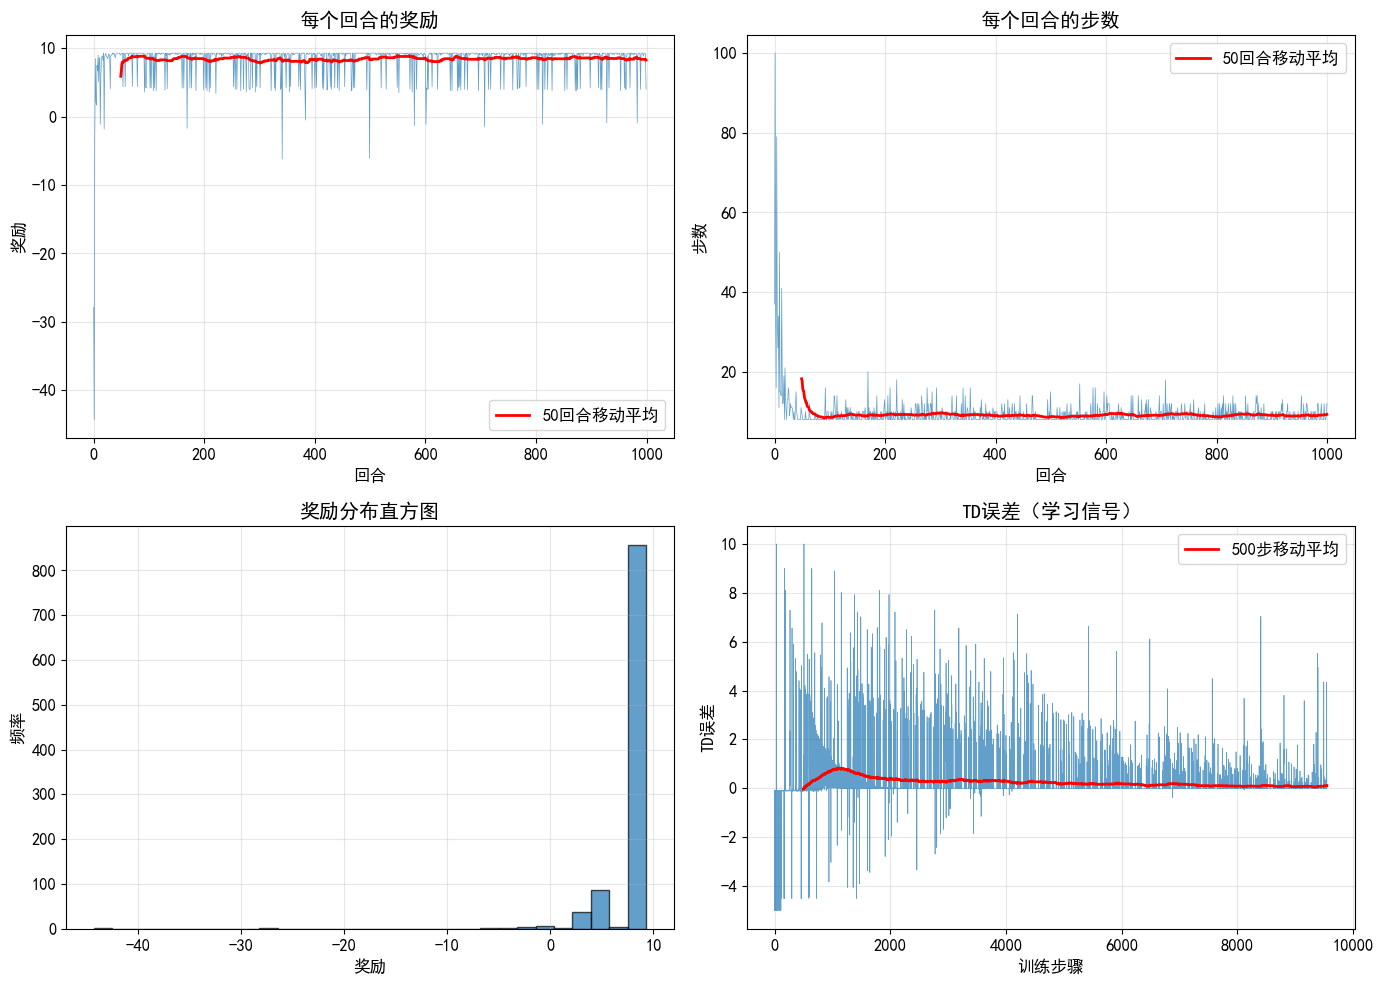


训练结果统计：
总回合数：1000
平均奖励：8.33
平均步数：9.55
最大奖励：9.30
最小奖励：-44.30
最近100回合平均奖励：8.45
模型已收敛：智能体学会了高效到达目标

5. 测试智能体性能

开始测试，测试回合数：10

测试结果统计：
平均奖励：9.30 ± 0.00
平均步数：8.00 ± 0.00
成功率：100.0%

6. 演示一个回合的详细过程

开始测试，测试回合数：1

=== 测试回合 1 ===
步骤: 0
A . . . .
. X . . .
. . . X .
. X . . .
. . . . G
----------
步骤 1: 动作=右, 奖励=-0.10, 信息=正常移动
步骤: 1
S A . . .
. X . . .
. . . X .
. X . . .
. . . . G
----------
步骤 2: 动作=右, 奖励=-0.10, 信息=正常移动
步骤: 2
S . A . .
. X . . .
. . . X .
. X . . .
. . . . G
----------
步骤 3: 动作=下, 奖励=-0.10, 信息=正常移动
步骤: 3
S . . . .
. X A . .
. . . X .
. X . . .
. . . . G
----------
步骤 4: 动作=下, 奖励=-0.10, 信息=正常移动
步骤: 4
S . . . .
. X . . .
. . A X .
. X . . .
. . . . G
----------
步骤 5: 动作=下, 奖励=-0.10, 信息=正常移动
步骤: 5
S . . . .
. X . . .
. . . X .
. X A . .
. . . . G
----------
步骤 6: 动作=右, 奖励=-0.10, 信息=正常移动
步骤: 6
S . . . .
. X . . .
. . . X .
. X . A .
. . . . G
----------
步骤 7: 动作=右, 奖励=-0.10, 信息=正常移动
步骤: 7
S . . . .
. X . . .
. . . X .
. X . . A
. . . . G
----------
步骤 8: 动作=下, 奖励=10.00, 信息=到达目标


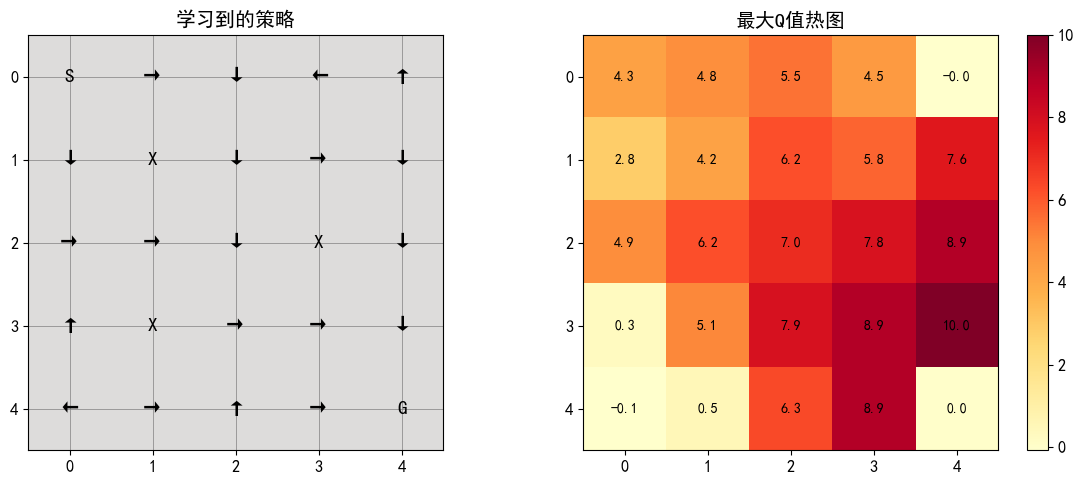


强化学习教学演示完成！


In [9]:
"""
强化学习教学代码：自定义网格世界环境中的Q-learning实现

作者：DeepSeek
日期：2024年

本代码实现了一个简单的强化学习教学示例，包括：
1. 自定义网格世界环境
2. Q-learning算法实现
3. 完整的训练和测试流程
4. 结果可视化

数学原理：
Q-learning是基于值函数的强化学习算法，通过贝尔曼方程更新Q值：
Q(s,a) ← Q(s,a) + α[r + γ·max_a'Q(s',a') - Q(s,a)]
其中：
- α：学习率，控制新信息覆盖旧信息的程度
- γ：折扣因子，表示未来奖励的重要性
- r：即时奖励
- s：当前状态，a：当前动作
- s'：下一个状态，a'：下一个动作

ε-greedy策略：以ε的概率进行探索（随机选择动作），以1-ε的概率进行利用（选择Q值最大的动作）
"""

import numpy as np
import matplotlib.pyplot as plt
import random
import time
from IPython.display import clear_output  # 用于在Jupyter notebook中清空输出
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
plt.rcParams['font.size'] = 12                # 设置字体大小
# 第一部分：自定义游戏环境类
class GridWorldEnv:
    """
    自定义网格世界环境

    环境要素：
    - 网格大小：5×5
    - 智能体初始位置：(0,0)
    - 目标位置：(4,4)
    - 障碍物：随机生成3-5个
    - 动作：上(0)、下(1)、左(2)、右(3)
    - 状态：网格位置(x,y)

    奖励设计说明：
    1. 到达目标：+10（正向激励，鼓励智能体完成任务）
    2. 碰到障碍物：-5（惩罚，避免无效行为）
    3. 每走一步：-0.1（鼓励高效到达目标，避免无意义徘徊）
    """

    def __init__(self, size=5, random_obstacles=True, num_obstacles=None):
        """
        初始化网格世界环境

        参数：
        size: 网格大小（默认5x5）
        random_obstacles: 是否随机生成障碍物
        num_obstacles: 障碍物数量，如果为None则随机生成3-5个
        """
        self.size = size  # 网格大小
        self.start_pos = (0, 0)  # 起始位置
        self.goal_pos = (size-1, size-1)  # 目标位置

        # 动作空间定义：上、下、左、右
        # 动作编号对应：0-上，1-下，2-左，3-右
        self.action_space = [0, 1, 2, 3]
        self.action_meaning = {
            0: "上",
            1: "下",
            2: "左",
            3: "右"
        }

        # 动作对应的坐标变化：上(-1,0), 下(1,0), 左(0,-1), 右(0,1)
        self.action_delta = {
            0: (-1, 0),  # 上：行减1
            1: (1, 0),   # 下：行加1
            2: (0, -1),  # 左：列减1
            3: (0, 1)    # 右：列加1
        }

        # 初始化障碍物
        self.obstacles = []
        if random_obstacles:
            # 如果未指定障碍物数量，随机生成3-5个
            if num_obstacles is None:
                num_obstacles = random.randint(3, 5)

            # 生成障碍物位置（不能与起点或终点重合）
            self.obstacles = []
            while len(self.obstacles) < num_obstacles:
                obstacle = (random.randint(0, size-1), random.randint(0, size-1))
                if (obstacle != self.start_pos and
                    obstacle != self.goal_pos and
                    obstacle not in self.obstacles):
                    self.obstacles.append(obstacle)
        else:
            # 固定障碍物位置，便于教学
            self.obstacles = [(1, 1), (2, 3), (3, 1)]

        # 当前状态（智能体位置）
        self.current_pos = self.start_pos

        # 记录步骤数（用于可视化）
        self.step_count = 0

        print(f"环境初始化完成：")
        print(f"- 网格大小：{size}x{size}")
        print(f"- 起点位置：{self.start_pos}")
        print(f"- 终点位置：{self.goal_pos}")
        print(f"- 障碍物位置：{self.obstacles}")
        print(f"- 动作空间：{list(self.action_meaning.values())}")

    def reset(self):
        """
        重置环境到初始状态

        返回：
        state: 初始状态（智能体位置）
        """
        self.current_pos = self.start_pos  # 重置智能体位置
        self.step_count = 0  # 重置步数计数器
        return self.current_pos

    def step(self, action):
        """
        执行一个动作，返回新的状态、奖励和是否终止

        参数：
        action: 动作（0-3）

        返回：
        next_state: 下一个状态（智能体新位置）
        reward: 奖励值
        done: 是否终止（到达目标或达到最大步数）
        info: 附加信息（可选）
        """
        # 获取动作对应的坐标变化
        delta = self.action_delta[action]

        # 计算新位置
        new_row = self.current_pos[0] + delta[0]
        new_col = self.current_pos[1] + delta[1]

        # 确保新位置在网格范围内（边界检查）
        new_row = max(0, min(new_row, self.size - 1))
        new_col = max(0, min(new_col, self.size - 1))

        new_pos = (new_row, new_col)

        # 初始化奖励和终止标志
        reward = -0.1  # 默认每走一步的惩罚
        done = False

        # 检查是否到达目标
        if new_pos == self.goal_pos:
            reward = 10.0  # 到达目标的奖励
            done = True
            info = "到达目标"
        # 检查是否碰到障碍物
        elif new_pos in self.obstacles:
            reward = -5.0  # 碰到障碍物的惩罚
            info = "碰到障碍物"
        else:
            info = "正常移动"

        # 更新当前位置
        self.current_pos = new_pos
        self.step_count += 1

        # 防止智能体无限循环（最多允许100步）
        if self.step_count >= 100:
            done = True
            info = "达到最大步数"

        return new_pos, reward, done, info

    def render(self, mode='human'):
        """
        可视化当前环境状态

        参数：
        mode: 渲染模式（'human'为打印文本，'rgb_array'为返回数组）
        """
        # 创建网格表示
        grid = []
        for i in range(self.size):
            row = []
            for j in range(self.size):
                pos = (i, j)
                if pos == self.current_pos:
                    row.append("A")  # 智能体
                elif pos == self.start_pos:
                    row.append("S")  # 起点
                elif pos == self.goal_pos:
                    row.append("G")  # 目标
                elif pos in self.obstacles:
                    row.append("X")  # 障碍物
                else:
                    row.append(".")  # 空位置
            grid.append(row)

        # 打印网格
        print(f"步骤: {self.step_count}")
        for row in grid:
            print(" ".join(row))
        print("-" * (self.size * 2))

        # 如果是rgb_array模式，返回用于matplotlib显示的数组
        if mode == 'rgb_array':
            # 创建颜色映射
            color_grid = np.zeros((self.size, self.size, 3))
            for i in range(self.size):
                for j in range(self.size):
                    pos = (i, j)
                    if pos == self.current_pos:
                        color_grid[i, j] = [0.2, 0.8, 0.2]  # 绿色：智能体
                    elif pos == self.start_pos:
                        color_grid[i, j] = [0.8, 0.8, 0.0]  # 黄色：起点
                    elif pos == self.goal_pos:
                        color_grid[i, j] = [0.0, 0.0, 1.0]  # 蓝色：目标
                    elif pos in self.obstacles:
                        color_grid[i, j] = [0.5, 0.5, 0.5]  # 灰色：障碍物
                    else:
                        color_grid[i, j] = [1.0, 1.0, 1.0]  # 白色：空位置
            return color_grid

    def get_state_index(self, state):
        """
        将状态（位置坐标）转换为索引

        参数：
        state: 状态（位置坐标）

        返回：
        index: 状态索引
        """
        # 将二维坐标转换为一维索引：index = row * size + col
        return state[0] * self.size + state[1]

    def get_total_states(self):
        """返回状态总数"""
        return self.size * self.size


# 第二部分：Q-learning算法实现
class QLearningAgent:
    """
    Q-learning算法实现

    使用ε-greedy策略平衡探索与利用：
    - 探索：随机选择动作，发现新策略
    - 利用：选择当前已知的最佳动作

    超参数选择说明：
    1. 学习率α=0.1：适中的学习速度，既能快速学习又不会过于激进
    2. 折扣因子γ=0.9：未来奖励的重要性较高，鼓励长期规划
    3. ε=0.1：10%的时间进行探索，90%的时间进行利用
    """

    def __init__(self, state_size, action_size, learning_rate=0.1,
                 discount_factor=0.9, epsilon=0.1):
        """
        初始化Q-learning智能体

        参数：
        state_size: 状态空间大小（状态数量）
        action_size: 动作空间大小（动作数量）
        learning_rate: 学习率α，控制学习速度（默认0.1）
        discount_factor: 折扣因子γ，未来奖励的折扣（默认0.9）
        epsilon: ε-greedy策略中的ε，探索概率（默认0.1）
        """
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate  # α
        self.discount_factor = discount_factor  # γ
        self.epsilon = epsilon  # ε

        # 初始化Q表：state_size行 × action_size列，初始值全为0
        # Q表存储每个状态-动作对的预期累积奖励
        self.q_table = np.zeros((state_size, action_size))

        print(f"Q-learning智能体初始化完成：")
        print(f"- 状态空间大小：{state_size}")
        print(f"- 动作空间大小：{action_size}")
        print(f"- 学习率α：{learning_rate}")
        print(f"- 折扣因子γ：{discount_factor}")
        print(f"- 探索率ε：{epsilon}")
        print(f"- Q表形状：{self.q_table.shape}")

    def choose_action(self, state):
        """
        使用ε-greedy策略选择动作

        参数：
        state: 当前状态（状态索引）

        返回：
        action: 选择的动作（动作编号）
        """
        # ε-greedy策略：以ε的概率进行探索（随机选择动作）
        # 以1-ε的概率进行利用（选择Q值最大的动作）
        if np.random.rand() < self.epsilon:
            # 探索：随机选择一个动作
            action = np.random.randint(self.action_size)
            # print(f"探索：状态{state}，随机选择动作{action}")
        else:
            # 利用：选择当前状态下Q值最大的动作
            # 如果有多个动作具有相同的最大Q值，随机选择一个
            max_q = np.max(self.q_table[state])
            # 获取所有具有最大Q值的动作
            max_actions = np.where(self.q_table[state] == max_q)[0]
            # 从最大Q值动作中随机选择一个
            action = np.random.choice(max_actions)
            # print(f"利用：状态{state}，选择Q值最大动作{action}，Q值={max_q}")

        return action

    def learn(self, state, action, reward, next_state, done):
        """
        Q-learning更新规则：
        Q(s,a) ← Q(s,a) + α[r + γ·max_a'Q(s',a') - Q(s,a)]

        参数：
        state: 当前状态s（状态索引）
        action: 执行的动作a（动作编号）
        reward: 获得的奖励r
        next_state: 下一个状态s'（状态索引）
        done: 是否终止（布尔值）
        """
        # 获取当前Q值：Q(s,a)
        current_q = self.q_table[state, action]

        if done:
            # 如果已经终止，没有下一个状态，目标Q值就是即时奖励
            target_q = reward
        else:
            # 否则，目标Q值 = 即时奖励 + γ * 下一个状态的最大Q值
            # max_a'Q(s',a')：下一个状态所有可能动作的最大Q值
            max_next_q = np.max(self.q_table[next_state])
            target_q = reward + self.discount_factor * max_next_q

        # 计算TD误差：目标Q值 - 当前Q值
        td_error = target_q - current_q

        # 更新Q值：Q(s,a) = Q(s,a) + α * (目标Q值 - 当前Q值)
        self.q_table[state, action] = current_q + self.learning_rate * td_error

        # 返回TD误差，可用于监控学习过程
        return td_error

    def get_best_action(self, state):
        """
        获取给定状态下的最佳动作（不进行探索）

        参数：
        state: 状态（状态索引）

        返回：
        action: 最佳动作
        """
        return np.argmax(self.q_table[state])

    def get_policy(self):
        """
        从Q表提取策略

        返回：
        policy: 每个状态的最佳动作数组
        """
        policy = np.argmax(self.q_table, axis=1)
        return policy


# 第三部分：训练函数
def train_agent(env, agent, episodes=1000, max_steps=100, render_every=100):
    """
    训练Q-learning智能体

    参数：
    env: 环境对象
    agent: 智能体对象
    episodes: 训练回合数（默认1000）
    max_steps: 每个回合最大步数（默认100）
    render_every: 每多少回合可视化一次（默认100）

    返回：
    rewards_history: 每个回合的奖励历史
    steps_history: 每个回合的步数历史
    td_errors: TD误差历史（用于监控学习过程）
    """
    print(f"开始训练，总回合数：{episodes}")

    # 初始化历史记录
    rewards_history = []
    steps_history = []
    td_errors = []

    for episode in range(episodes):
        # 重置环境，获取初始状态
        state = env.reset()
        state_idx = env.get_state_index(state)

        total_reward = 0
        step = 0

        # 开始一个回合的训练
        done = False
        while not done and step < max_steps:
            # 选择动作
            action = agent.choose_action(state_idx)

            # 执行动作
            next_state, reward, done, info = env.step(action)
            next_state_idx = env.get_state_index(next_state)

            # 学习（更新Q表）
            td_error = agent.learn(state_idx, action, reward, next_state_idx, done)
            td_errors.append(td_error)

            # 更新状态和累积奖励
            state_idx = next_state_idx
            total_reward += reward
            step += 1

            # 每隔一定回合可视化一次训练过程
            if episode % render_every == 0 and step == 1:
                print(f"\n回合 {episode}，步骤 {step}:")
                env.render()
                print(f"动作: {env.action_meaning[action]}, 奖励: {reward:.2f}, 信息: {info}")

        # 记录本回合的结果
        rewards_history.append(total_reward)
        steps_history.append(step)

        # 每100回合打印一次训练进度
        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards_history[-100:])
            avg_steps = np.mean(steps_history[-100:])
            print(f"回合 {episode+1}/{episodes} - "
                  f"平均奖励: {avg_reward:.2f}, "
                  f"平均步数: {avg_steps:.1f}")

    print("训练完成！")
    return rewards_history, steps_history, td_errors


# 第四部分：结果可视化
def plot_results(rewards_history, steps_history, td_errors=None):
    """
    绘制训练结果

    参数：
    rewards_history: 奖励历史
    steps_history: 步数历史
    td_errors: TD误差历史（可选）
    """
    # 创建包含多个子图的图形
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. 奖励历史图
    axes[0, 0].plot(rewards_history, linewidth=0.5, alpha=0.7)
    axes[0, 0].set_title('每个回合的奖励')
    axes[0, 0].set_xlabel('回合')
    axes[0, 0].set_ylabel('奖励')
    axes[0, 0].grid(True, alpha=0.3)

    # 计算移动平均（窗口大小为50）以观察趋势
    window_size = 50
    if len(rewards_history) >= window_size:
        moving_avg = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
        axes[0, 0].plot(range(window_size-1, len(rewards_history)), moving_avg,
                       'r-', linewidth=2, label=f'{window_size}回合移动平均')
        axes[0, 0].legend()

    # 2. 步数历史图
    axes[0, 1].plot(steps_history, linewidth=0.5, alpha=0.7)
    axes[0, 1].set_title('每个回合的步数')
    axes[0, 1].set_xlabel('回合')
    axes[0, 1].set_ylabel('步数')
    axes[0, 1].grid(True, alpha=0.3)

    # 步数移动平均
    if len(steps_history) >= window_size:
        moving_avg = np.convolve(steps_history, np.ones(window_size)/window_size, mode='valid')
        axes[0, 1].plot(range(window_size-1, len(steps_history)), moving_avg,
                       'r-', linewidth=2, label=f'{window_size}回合移动平均')
        axes[0, 1].legend()

    # 3. 奖励分布直方图
    axes[1, 0].hist(rewards_history, bins=30, edgecolor='black', alpha=0.7)
    axes[1, 0].set_title('奖励分布直方图')
    axes[1, 0].set_xlabel('奖励')
    axes[1, 0].set_ylabel('频率')
    axes[1, 0].grid(True, alpha=0.3)

    # 4. TD误差图（如果提供）
    if td_errors is not None:
        axes[1, 1].plot(td_errors, linewidth=0.5, alpha=0.7)
        axes[1, 1].set_title('TD误差（学习信号）')
        axes[1, 1].set_xlabel('训练步骤')
        axes[1, 1].set_ylabel('TD误差')
        axes[1, 1].grid(True, alpha=0.3)

        # TD误差的移动平均
        if len(td_errors) >= window_size*10:  # 使用更大的窗口，因为TD误差数据点更多
            td_window = window_size * 10
            moving_avg = np.convolve(td_errors, np.ones(td_window)/td_window, mode='valid')
            axes[1, 1].plot(range(td_window-1, len(td_errors)), moving_avg,
                          'r-', linewidth=2, label=f'{td_window}步移动平均')
            axes[1, 1].legend()
    else:
        # 如果不提供TD误差，绘制奖励的累积和
        cumulative_rewards = np.cumsum(rewards_history)
        axes[1, 1].plot(cumulative_rewards)
        axes[1, 1].set_title('累积奖励')
        axes[1, 1].set_xlabel('回合')
        axes[1, 1].set_ylabel('累积奖励')
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 打印统计信息
    print("\n训练结果统计：")
    print(f"总回合数：{len(rewards_history)}")
    print(f"平均奖励：{np.mean(rewards_history):.2f}")
    print(f"平均步数：{np.mean(steps_history):.2f}")
    print(f"最大奖励：{np.max(rewards_history):.2f}")
    print(f"最小奖励：{np.min(rewards_history):.2f}")

    # 检查收敛性：如果最近100回合的平均奖励稳定且接近最大值，可以认为收敛
    if len(rewards_history) >= 100:
        recent_avg = np.mean(rewards_history[-100:])
        print(f"最近100回合平均奖励：{recent_avg:.2f}")
        if recent_avg > 8.0:  # 设置收敛阈值（最大奖励为10）
            print("模型已收敛：智能体学会了高效到达目标")
        else:
            print("模型可能尚未完全收敛，考虑增加训练回合数")


# 第五部分：测试和演示
def test_agent(env, agent, episodes=10, render=True):
    """
    测试训练好的智能体

    参数：
    env: 环境对象
    agent: 训练好的智能体对象
    episodes: 测试回合数（默认10）
    render: 是否可视化测试过程（默认True）
    """
    print(f"\n开始测试，测试回合数：{episodes}")

    total_rewards = []
    total_steps = []

    for episode in range(episodes):
        # 重置环境
        state = env.reset()
        state_idx = env.get_state_index(state)

        done = False
        step = 0
        total_reward = 0

        if render:
            print(f"\n=== 测试回合 {episode+1} ===")
            env.render()

        # 执行一个测试回合
        while not done:
            # 使用训练好的策略（不进行探索）
            action = agent.get_best_action(state_idx)

            # 执行动作
            next_state, reward, done, info = env.step(action)
            next_state_idx = env.get_state_index(next_state)

            # 更新状态
            state_idx = next_state_idx
            total_reward += reward
            step += 1

            if render:
                print(f"步骤 {step}: 动作={env.action_meaning[action]}, 奖励={reward:.2f}, 信息={info}")
                env.render()
                time.sleep(0.1)  # 短暂暂停以便观察

        # 记录本回合结果
        total_rewards.append(total_reward)
        total_steps.append(step)

        if render:
            print(f"回合 {episode+1} 完成: 总奖励={total_reward:.2f}, 步数={step}")

    # 打印测试结果
    print("\n测试结果统计：")
    print(f"平均奖励：{np.mean(total_rewards):.2f} ± {np.std(total_rewards):.2f}")
    print(f"平均步数：{np.mean(total_steps):.2f} ± {np.std(total_steps):.2f}")
    print(f"成功率：{sum(1 for r in total_rewards if r > 0) / episodes * 100:.1f}%")

    return total_rewards, total_steps


def visualize_policy(env, agent):
    """
    可视化学习到的策略

    参数：
    env: 环境对象
    agent: 训练好的智能体对象
    """
    # 获取策略：每个状态的最佳动作
    policy = agent.get_policy()

    # 创建策略可视化网格
    policy_grid = []
    for i in range(env.size):
        row = []
        for j in range(env.size):
            state_idx = env.get_state_index((i, j))
            action = policy[state_idx]
            # 将动作编号转换为箭头符号
            arrow = {
                0: "↑",  # 上
                1: "↓",  # 下
                2: "←",  # 左
                3: "→"   # 右
            }[action]

            # 标记特殊位置
            pos = (i, j)
            if pos == env.start_pos:
                row.append("S")
            elif pos == env.goal_pos:
                row.append("G")
            elif pos in env.obstacles:
                row.append("X")
            else:
                row.append(arrow)
        policy_grid.append(row)

    print("\n学习到的策略（每个位置的最佳动作）：")
    for row in policy_grid:
        print(" ".join(row))

    # 可视化Q值热图（每个状态的最大Q值）
    max_q_values = np.max(agent.q_table, axis=1).reshape((env.size, env.size))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 策略可视化
    ax1 = axes[0]
    im1 = ax1.imshow(np.zeros((env.size, env.size)), cmap='coolwarm', vmin=-1, vmax=1)

    # 添加文本
    for i in range(env.size):
        for j in range(env.size):
            ax1.text(j, i, policy_grid[i][j],
                    ha='center', va='center', fontsize=14,
                    fontweight='bold' if policy_grid[i][j] in ['S', 'G', 'X'] else 'normal')

    ax1.set_xticks(range(env.size))
    ax1.set_yticks(range(env.size))
    ax1.grid(True, which='both', color='gray', linewidth=0.5)
    ax1.set_title('学习到的策略')

    # Q值热图
    ax2 = axes[1]
    im2 = ax2.imshow(max_q_values, cmap='YlOrRd')

    # 添加Q值文本
    for i in range(env.size):
        for j in range(env.size):
            ax2.text(j, i, f"{max_q_values[i, j]:.1f}",
                    ha='center', va='center', fontsize=10)

    ax2.set_xticks(range(env.size))
    ax2.set_yticks(range(env.size))
    ax2.set_title('最大Q值热图')
    plt.colorbar(im2, ax=ax2)

    plt.tight_layout()
    plt.show()


# 第六部分：主函数
def main():
    """
    主函数：整合所有组件

    执行流程：
    1. 创建网格世界环境
    2. 创建Q-learning智能体
    3. 训练智能体
    4. 可视化训练结果
    5. 测试智能体性能
    6. 可视化学习到的策略
    """
    print("=" * 60)
    print("强化学习教学代码：Q-learning在网格世界中的应用")
    print("=" * 60)

    # 1. 创建环境
    print("\n1. 创建网格世界环境")
    env = GridWorldEnv(size=5, random_obstacles=False)  # 使用固定障碍物便于教学

    # 2. 创建智能体
    print("\n2. 创建Q-learning智能体")
    state_size = env.get_total_states()  # 状态总数：5x5=25
    action_size = len(env.action_space)  # 动作总数：4
    agent = QLearningAgent(state_size, action_size,
                          learning_rate=0.1,   # 学习率α：适中的学习速度
                          discount_factor=0.9, # 折扣因子γ：重视未来奖励
                          epsilon=0.1)         # 探索率ε：10%的时间进行探索

    # 3. 训练智能体
    print("\n3. 开始训练智能体")
    # 训练1000回合，每100回合可视化一次
    rewards_history, steps_history, td_errors = train_agent(
        env, agent, episodes=1000, max_steps=100, render_every=100
    )

    # 4. 可视化训练结果
    print("\n4. 可视化训练结果")
    plot_results(rewards_history, steps_history, td_errors)

    # 5. 测试智能体
    print("\n5. 测试智能体性能")
    # 先不渲染详细过程，只显示统计结果
    test_rewards, test_steps = test_agent(env, agent, episodes=10, render=False)

    # 再演示一个回合的详细过程
    print("\n6. 演示一个回合的详细过程")
    test_agent(env, agent, episodes=1, render=True)

    # 7. 可视化学习到的策略
    print("\n7. 可视化学习到的策略和Q值")
    visualize_policy(env, agent)

    print("\n" + "=" * 60)
    print("强化学习教学演示完成！")
    print("=" * 60)


# 如果直接运行此脚本，执行主函数
if __name__ == "__main__":
    main()